<a href="https://colab.research.google.com/github/sabanasersaleem-oss/QSmartGrid-Quantum-AI/blob/main/Q_SmartGrid_Prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⚙ Quantum Circuit:
B0: ───H───@───────────M('result')───
           │           │
B1: ───H───X───@───────M─────────────
               │       │
B2: ───H───────X───@───M─────────────
                   │   │
B3: ───H───────────X───M─────────────


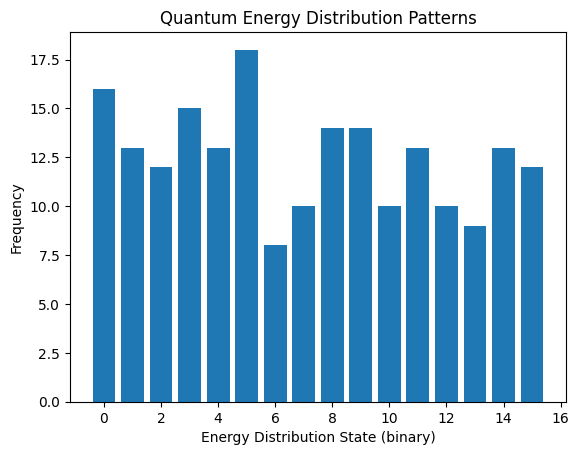


🔋 Forecasted vs Optimized Energy Usage (kWh)
Building 1: 1106.6 → 801.4  (-27.6%)
Building 2: 925.8 → 821.9  (-11.2%)
Building 3: 963.5 → 677.5  (-29.7%)
Building 4: 817.5 → 659.7  (-19.3%)

🧠 Gemini-style Recommendation:
 
Q-SmartGrid Quantum Analysis Summary:
- Average predicted demand: 953.3 kWh
- Optimized quantum distribution saved ≈ 21.9 %
- Recommended action: reduce non-critical loads in Building 2 & 4 during 6–9 PM.



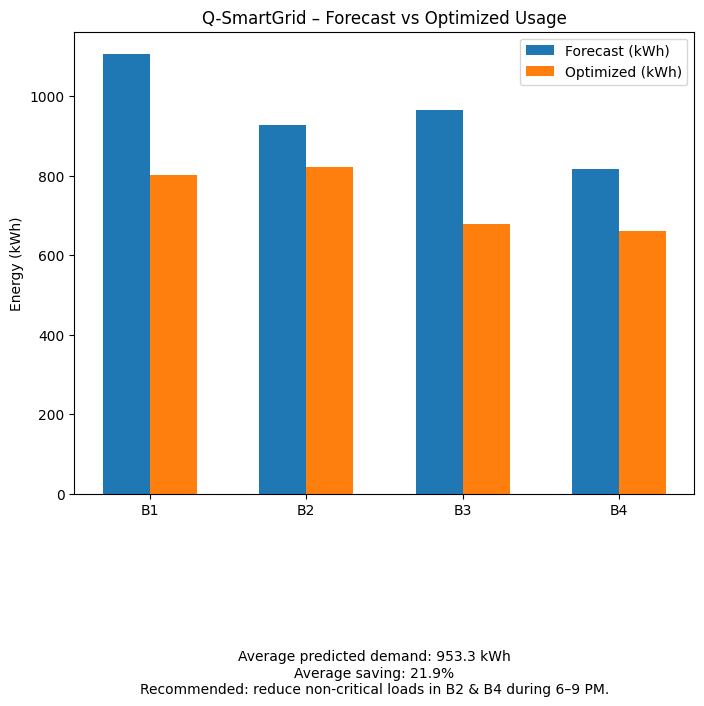

In [ ]:
!pip install --quiet cirq numpy matplotlib

import cirq, numpy as np, matplotlib.pyplot as plt, random

#  تعريف الكيوبتات (تمثل 4 مباني جامعية)
qubits = [cirq.NamedQubit(f"B{i}") for i in range(4)]

#  إنشاء دائرة كوانتية بسيطة
circuit = cirq.Circuit()
for q in qubits:
    circuit.append(cirq.H(q))        # توزيع احتمالات متوازنة
for i in range(3):
    circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))
circuit.append(cirq.measure(*qubits, key='result'))

print("⚙ Quantum Circuit:")
print(circuit)

#  تشغيل المحاكي
sim = cirq.Simulator()
result = sim.run(circuit, repetitions=200)
hist = result.histogram(key='result')

#  عرض النتائج بيانياً (نمط الحالات الكوانتية)
plt.bar(hist.keys(), hist.values())
plt.title("Quantum Energy Distribution Patterns")
plt.xlabel("Energy Distribution State (binary)")
plt.ylabel("Frequency")
plt.show()

#  محاكاة Vertex AI Forecast (عشوائي للتجريب)
forecast = [random.uniform(800, 1200) for _ in range(4)]
optimized = [f * random.uniform(0.7, 0.9) for f in forecast]

print("\n🔋 Forecasted vs Optimized Energy Usage (kWh)")
reductions = []
for i in range(4):
    red = (1 - optimized[i]/forecast[i]) * 100
    reductions.append(red)
    print(f"Building {i+1}: {forecast[i]:.1f} → {optimized[i]:.1f}  (-{red:.1f}%)")

#  توليد تقرير نصي بأسلوب Gemini Pro (تمثيلي)
avg_demand = np.mean(forecast)
avg_saving = np.mean(reductions)

summary = f"""
Q-SmartGrid Quantum Analysis Summary:
- Average predicted demand: {avg_demand:.1f} kWh
- Optimized quantum distribution saved ≈ {avg_saving:.1f} %
- Recommended action: reduce non-critical loads in Building 2 & 4 during 6–9 PM.
"""
print("\n🧠 Gemini-style Recommendation:\n", summary)

# =====================================================
#  (2) إنشاء صورة نهائية تلخص النتائج كاملة
# =====================================================

buildings = np.arange(1, 5)

plt.figure(figsize=(8, 6))
# أعمدة قبل التحسين
plt.bar(buildings - 0.15, forecast, width=0.3, label="Forecast (kWh)")
# أعمدة بعد التحسين
plt.bar(buildings + 0.15, optimized, width=0.3, label="Optimized (kWh)")

plt.xticks(buildings, [f"B{i}" for i in buildings])
plt.ylabel("Energy (kWh)")
plt.title("Q-SmartGrid – Forecast vs Optimized Usage")

plt.legend()

# نص ملخص أسفل الرسم
text_str = (
    f"Average predicted demand: {avg_demand:.1f} kWh\n"
    f"Average saving: {avg_saving:.1f}%\n"
    "Recommended: reduce non-critical loads in B2 & B4 during 6–9 PM."
)

# نستخدم إحداثيات نسبية (أسفل الشكل)
plt.gcf().text(0.5, -0.15, text_str, ha="center", va="top")

# حفظ الصورة بدقة عالية (تقدري تحمليها من Files في Colab)
plt.savefig("QSmartGrid_FinalResult.png", dpi=300, bbox_inches="tight")
plt.show()
